# **1. SETUP LIBRARIES**



These libraries and tools were imported to provide essential functions for data manipulation, model building, evaluation, and visualization, ensuring an efficient and streamlined process for building and assessing classification models for diabetes prediction.

In [3]:
#================ SET-UP ================

# General Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# ML Libraries
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.exceptions import NotFittedError

# Classification Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

print("Libraries imported successfully.")

Libraries imported successfully.


# **2. LOADING DATASET**

This code reads the data from the Testing.csv file and stores it in a Pandas DataFrame (df), preparing it for subsequent analysis and processing.

In [4]:
#================ LOAD ================

df = pd.read_csv('/content/Testing.csv')

# 3. **PREPROCESSING (DATA CLEANING)**

The goal of this code is to handle missing data and prepare the dataset for modeling. First, the code prints the column names and previews the first few rows to understand the structure of the data. It then identifies columns where zeros might represent missing values, specifically in the Glucose, BloodPressure, SkinThickness, Insulin, and BMI columns. These zero values are replaced with NaN so that they can be properly handled during the imputation process.

Next, a SimpleImputer from Scikit-learn is used to impute these NaN values. The imputer is set to replace the missing values with the median of the respective column, which is a common approach to deal with numerical data in machine learning. This is done to ensure that the model does not receive invalid or incomplete data, which could affect its performance.

After imputation, the code checks the DataFrame’s structure and statistics to confirm that the imputation was successful. The .info() method provides an overview of the data types and counts of non-null entries, while .describe() offers a summary of the data's statistical properties. Finally, the code checks for any remaining missing values using .isnull().sum(), ensuring that there are no gaps in the data before proceeding with the modeling process.

In [5]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,9,120,72,22,56,20.8,0.733,48,0
1,1,71,62,0,0,21.8,0.416,26,0
2,8,74,70,40,49,35.3,0.705,39,0
3,5,88,78,30,0,27.6,0.258,37,0
4,10,115,98,0,0,24.0,1.022,34,0


In [7]:
#Define Columns with Zeroes as Nan
from sklearn.impute import SimpleImputer

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

In [8]:
#Impute Nan values with median
imputer = SimpleImputer(strategy='median')
df[cols_with_zeros] = imputer.fit_transform(df[cols_with_zeros])

print("\nMissing '0' values in relevant columns have been imputed with their medians.")



Missing '0' values in relevant columns have been imputed with their medians.


In [9]:
#Check if there are nulls
print("\nDataFrame Information after imputation:")
df.info()


DataFrame Information after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               308 non-null    int64  
 1   Glucose                   308 non-null    float64
 2   BloodPressure             308 non-null    float64
 3   SkinThickness             308 non-null    float64
 4   Insulin                   308 non-null    float64
 5   BMI                       308 non-null    float64
 6   DiabetesPedigreeFunction  308 non-null    float64
 7   Age                       308 non-null    int64  
 8   Outcome                   308 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 21.8 KB


# **4. DESCRIPTIVE STATISTICS**

This output is a statistical summary of your DataFrame (df) after a crucial step: imputation.

The most important line here, considering the context of imputation, is the count row. It shows that every single column (Pregnancies, Glucose, BloodPressure, etc.) now has 308 non-null entries. This confirms that your imputation process was successful in filling any missing values, resulting in a complete dataset of 308 observations for all features.

The remaining rows (mean, std, min, 25%, 50%, 75%, max) provide a quick overview of the central tendency, spread, and range of values for each numerical feature, allowing us to understand the data's distribution after the missing values have been handled.

In [10]:
print("\nDescription of DataFrame after imputation:")
display(df.describe())

print("\nChecking for any remaining explicit null values:")
print(df.isnull().sum())


Description of DataFrame after imputation:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,3.863636,120.363636,72.866883,29.753247,140.152597,32.286039,0.445042,33.730519,0.301948
std,3.381437,30.423251,12.315815,8.933202,75.000843,6.462561,0.297660,12.208374,0.459850
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,98.000000,64.000000,26.000000,126.000000,27.600000,0.228250,24.000000,0.000000
50%,3.000000,117.000000,74.000000,30.000000,126.500000,32.350000,0.348000,29.000000,0.000000
75%,6.000000,136.000000,80.000000,32.000000,127.750000,36.425000,0.600000,42.000000,1.000000
max,13.000000,199.000000,114.000000,99.000000,600.000000,57.300000,1.699000,70.000000,1.000000



Checking for any remaining explicit null values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# **5. EXPLORATORY DATA ANALYSIS**

**5.1. Scatterplot**

A scatter plot was generated to explore the relationship between Glucose levels and BMI, with the data points colored based on diabetes Outcome (0 = no diabetes, 1 = diabetes). A quadratic regression line (2nd-degree polynomial) was fitted separately for each outcome group to highlight potential nonlinear trends in the data. This allows visual comparison of the relationships for diabetic and non-diabetic individuals.

The scatter plot shows that individuals with higher glucose levels tend to have higher BMI values, particularly among those with diabetes (Outcome = 1, red). The quadratic regression lines indicate a subtle upward trend for both groups, but the trend is more pronounced for the diabetic group. This suggests a potential nonlinear relationship where higher glucose levels are more strongly associated with increased BMI among individuals diagnosed with diabetes. However, there is significant overlap among the data points of both outcomes, indicating that BMI and Glucose alone cannot perfectly distinguish between individuals with and without diabetes. This overlap suggests that while these features are correlated with diabetes, they are not sufficient by themselves for accurate classification.

The visualized data supports the hypothesis that glucose and BMI are positively correlated, especially for diabetic individuals. This implies that individuals with higher BMI might be at greater risk of developing diabetes when glucose levels are also elevated. The separation in regression lines further reinforces the usefulness of BMI and glucose as combined indicators for diabetes risk profiling, but it also highlights the need to consider additional features for a more reliable prediction.

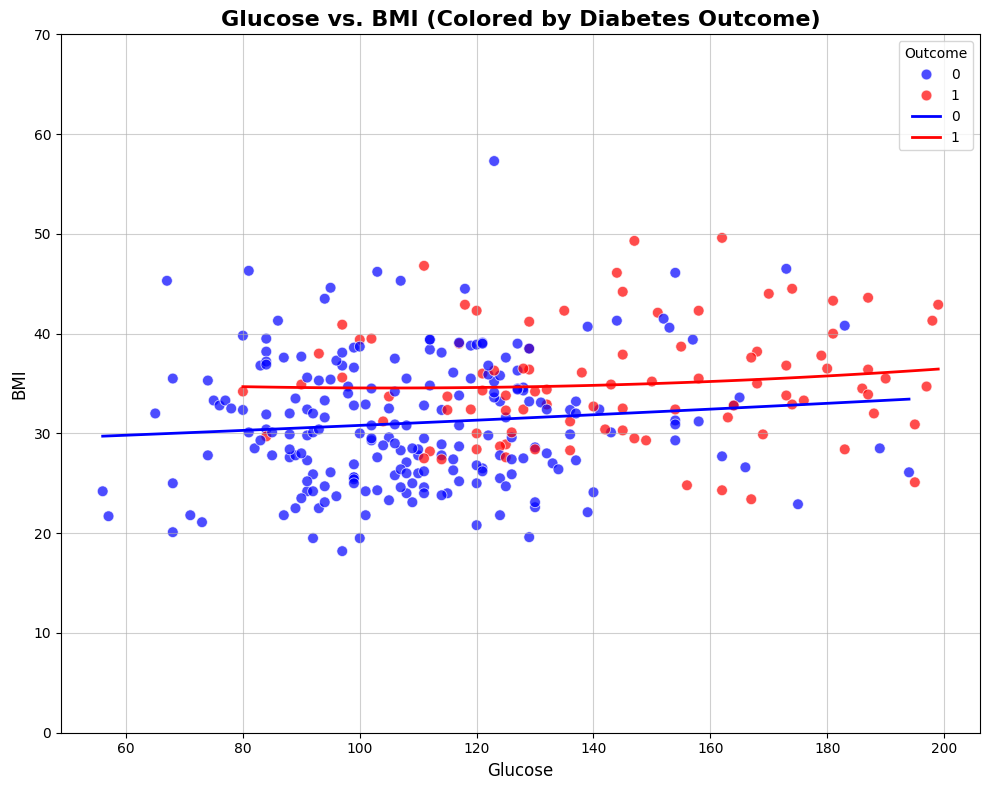

In [11]:
#Plot Glucose vs BMI segregated by Diabetes Outcome to find correlation
outcome_colors = {
    0: '#0000FF',  # Outcome 0
    1: '#FF0000'   # Outcome 1
}

plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    data=df,
    x='Glucose',
    y='BMI',
    hue='Outcome',
    palette=outcome_colors,
    alpha=0.7,
    s=60
)
# Add quadratic regression lines for Outcome = 0 and 1
for outcome_value in [0, 1]:
    subset = df[df['Outcome'] == outcome_value]
    x = subset['Glucose']
    y = subset['BMI']

    # Fit a 2nd-degree polynomial
    coeffs = np.polyfit(x, y, deg=2)
    poly = np.poly1d(coeffs)

    # Plot the polynomial line
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = poly(x_vals)

    plt.plot(
        x_vals, y_vals,
        label=f'{outcome_value}',
        linestyle='-',
        linewidth=2,
        color=outcome_colors[outcome_value]
    )

plt.title('Glucose vs. BMI (Colored by Diabetes Outcome)', fontsize=16, weight='bold')
plt.xlabel("Glucose", fontsize=12)
plt.ylabel("BMI", fontsize=12)
plt.legend(title="Outcome")
plt.ylim(0, 70)
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()
plt.show()

**5.2. Pairplot**

A pairplot was created to explore how each feature in the diabetes dataset may contribute to the presence of diabetes. The features included in the dataset are: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age. These are standard medical attributes collected from patients, and the goal of the plot is to observe how these features relate to each other and to the diabetes outcome.

The visualization was done using Seaborn’s pairplot() function, with the hue parameter set to 'Outcome' to differentiate between diabetic (1, in red) and non-diabetic (0, in blue) individuals. The diagonal of the plot displays kernel density estimates to show the distribution of each feature, while the lower triangle of the matrix contains scatterplots showing relationships between feature pairs. Transparency (alpha=0.4) and marker size (s=15) were adjusted to handle overlapping points, and corner=True was used to remove duplicate plots from the upper triangle.

The diagonal KDE plots indicate how each feature is distributed across the two outcome groups. Glucose shows the most noticeable difference, with diabetic individuals generally having higher glucose values. BMI and Age also show some separation, suggesting that higher values are more common among diabetic cases. Pregnancies and DiabetesPedigreeFunction show moderate differences, while Insulin, SkinThickness, and BloodPressure have a lot of overlap between the two groups, making them less visually informative.

The scatterplots further highlight how features interact. There is a visible positive relationship between Glucose and BMI, especially for diabetic individuals. Age and Pregnancies also appear to be correlated, which is expected. BMI and Insulin show a weak trend, but the insulin values are widely spread, reducing clarity. Other feature combinations do not show strong patterns that clearly separate the two outcome groups.

Based on the pairplot, Glucose appears to have the strongest association with the diabetes outcome. BMI and Age also show some level of contribution, with diabetic individuals tending to have higher values in these features. On the other hand, features like SkinThickness, Insulin, and BloodPressure do not show clear visual separation and may have a weaker relationship with the outcome. Overall, this visualization helps in identifying which features in the dataset might be more influential in predicting whether a person has diabetes.

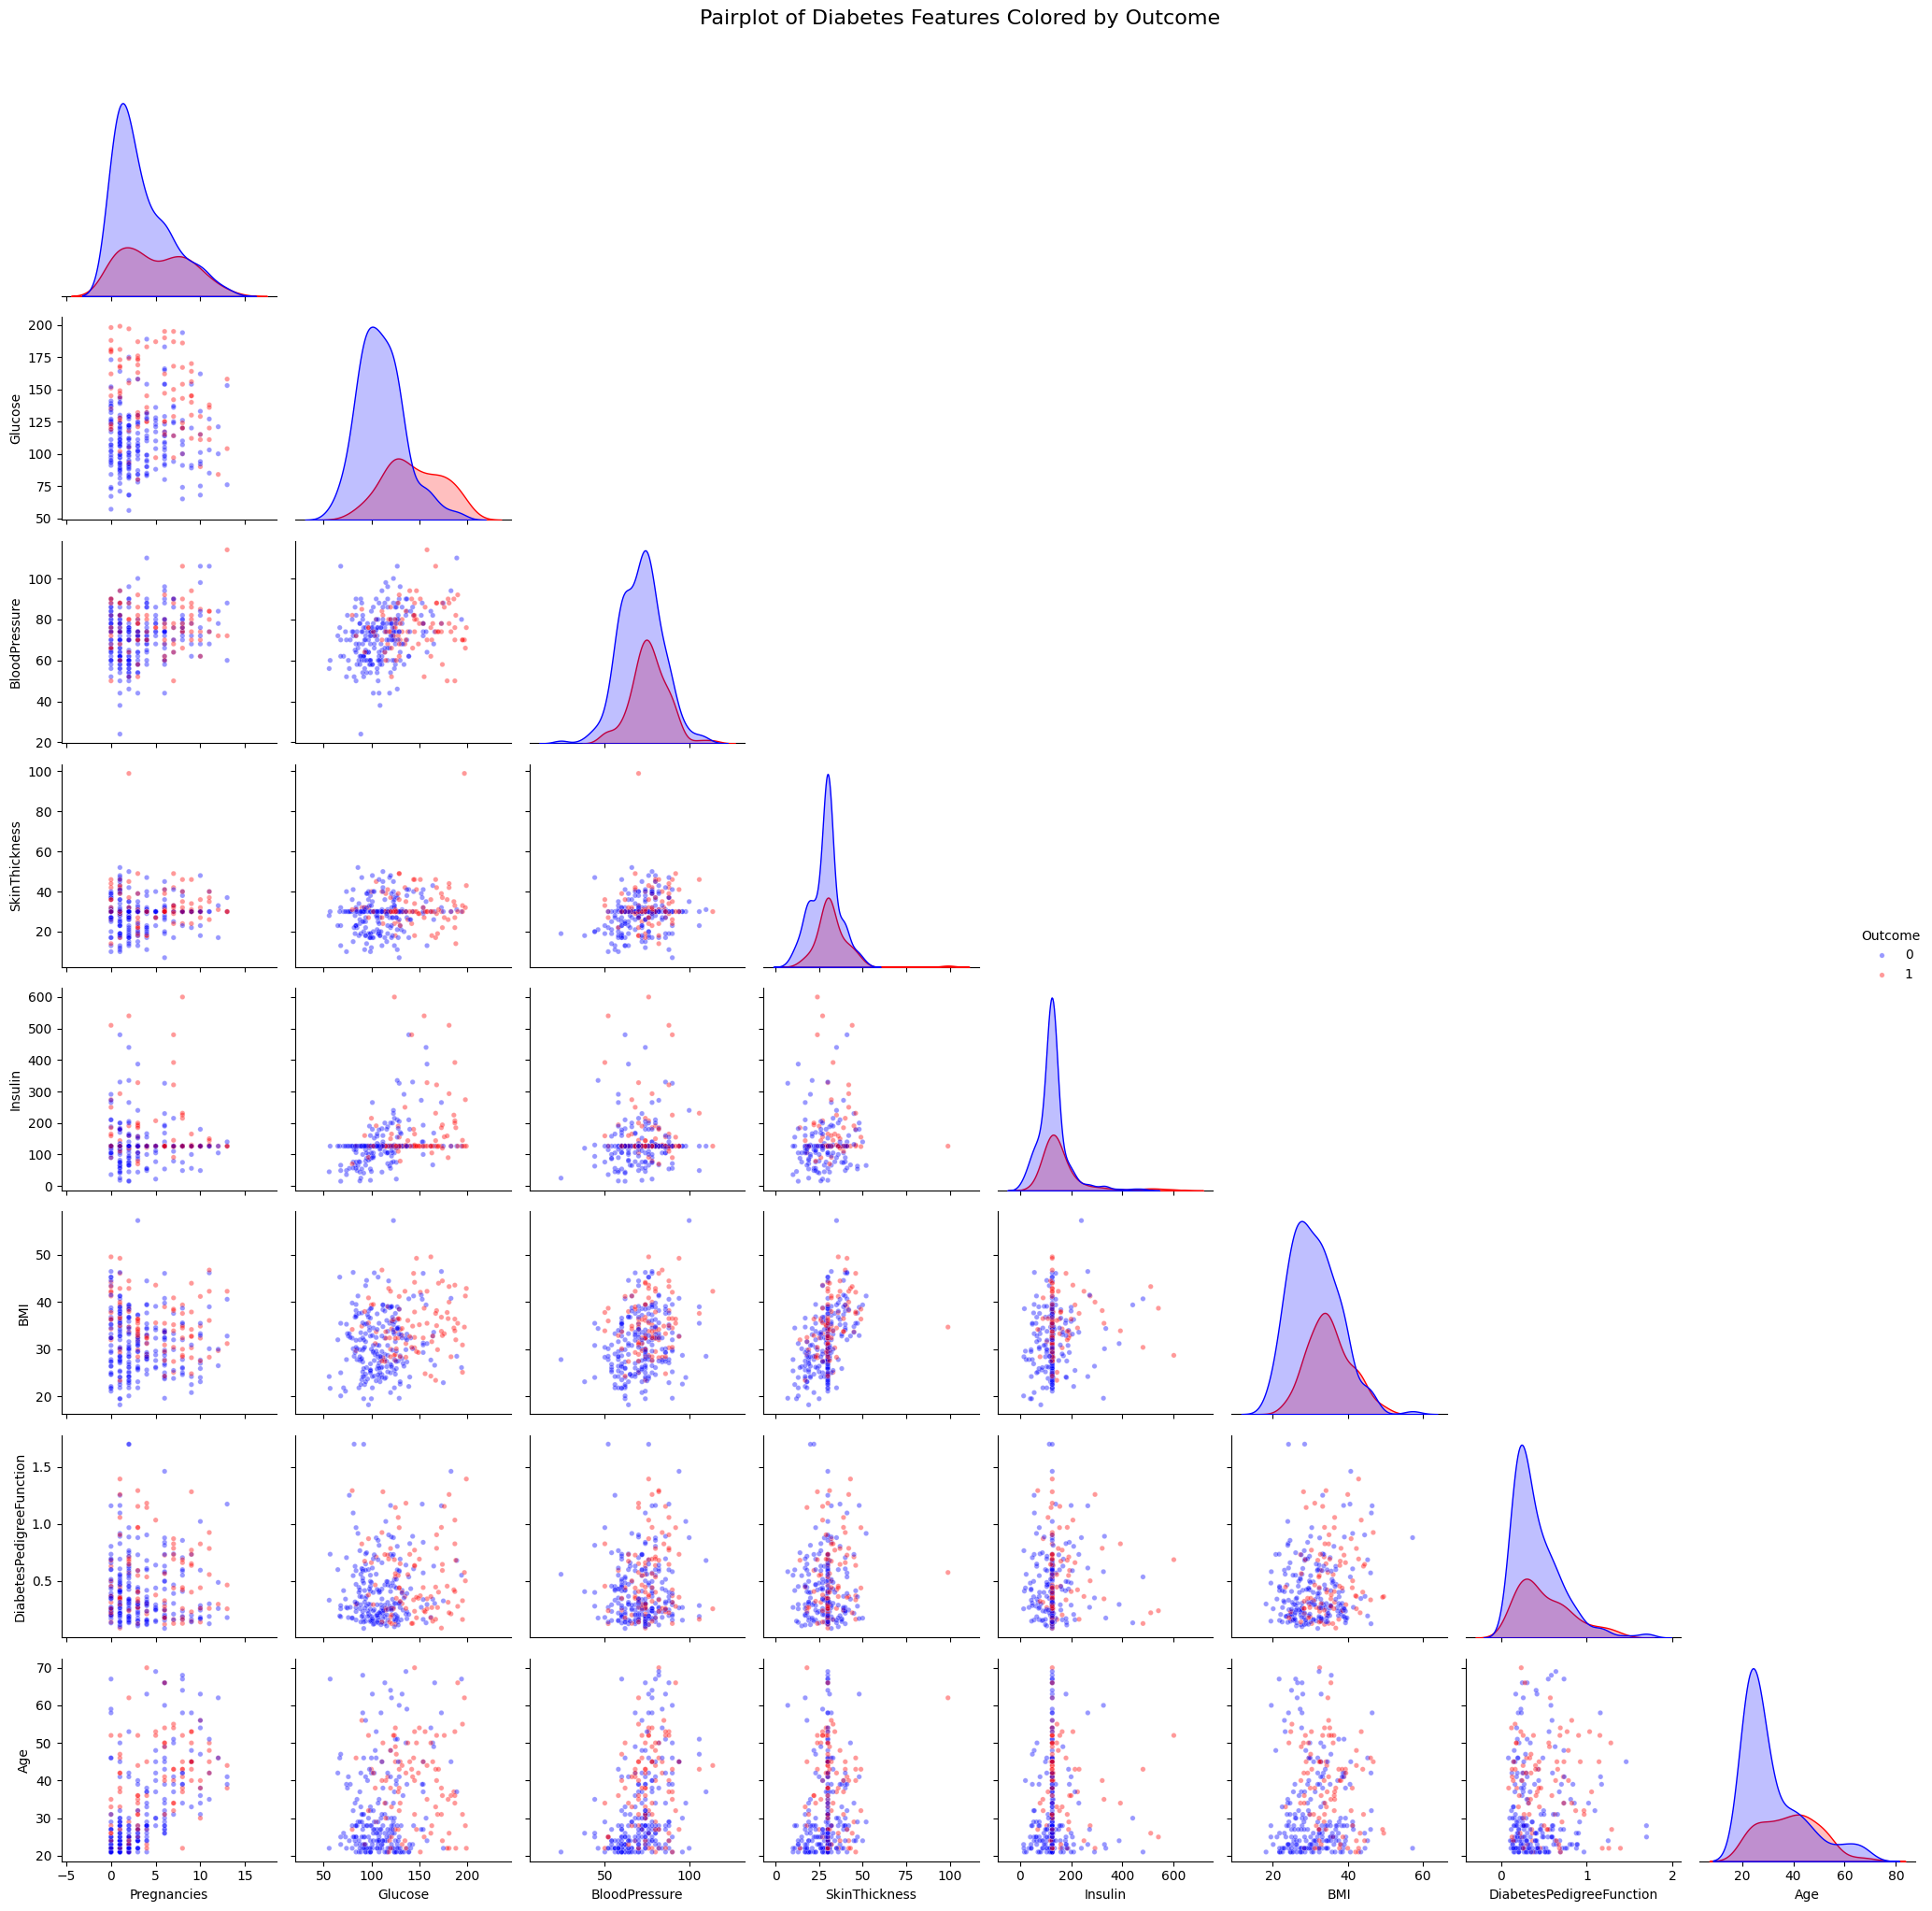

In [12]:
feature_columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

# Generate the pairplot
sns.pairplot(
    data=df,
    vars=feature_columns,
    hue='Outcome',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    corner=True,
    palette=outcome_colors,
)

plt.suptitle('Pairplot of Diabetes Features Colored by Outcome', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**5.3. Correlation Matrix (Heatmap)**

A correlation matrix was plotted to examine the linear relationships between all features in the dataset, including the diabetes outcome. This helps identify which variables are most strongly associated with diabetes and can guide the prioritization of features for further analysis or modeling. The heatmap displays correlation values ranging from -1 (strong negative) to +1 (strong positive), with colors indicating the strength and direction of these relationships.

Glucose has the strongest correlation with the diabetes outcome (0.51), meaning people with higher glucose levels are more likely to have diabetes. BMI (0.28) and Age (0.26) also show moderate links, suggesting that people who are older or have higher BMI are also at higher risk.

Insulin, SkinThickness, and Pregnancies have weaker but still positive correlations with the outcome (around 0.21–0.22). This means they may still play a role but are not as strong. DiabetesPedigreeFunction (0.15) and BloodPressure (0.18) have the lowest correlations, so they likely have less impact in predicting diabetes.

Some features are related to each other — for example, BMI and SkinThickness are fairly correlated (0.49), and Age and Pregnancies are strongly related (0.55), likely because older people tend to have had more pregnancies.

The correlation matrix confirms that Glucose is the most important linear predictor of diabetes in this dataset, followed by BMI and Age. These features should be prioritized in analysis or modeling. Other features like Insulin, Pregnancies, and SkinThickness show some association, but to a lesser extent. Features such as DiabetesPedigreeFunction and BloodPressure appear to have limited predictive power based on their weak correlations with the outcome.

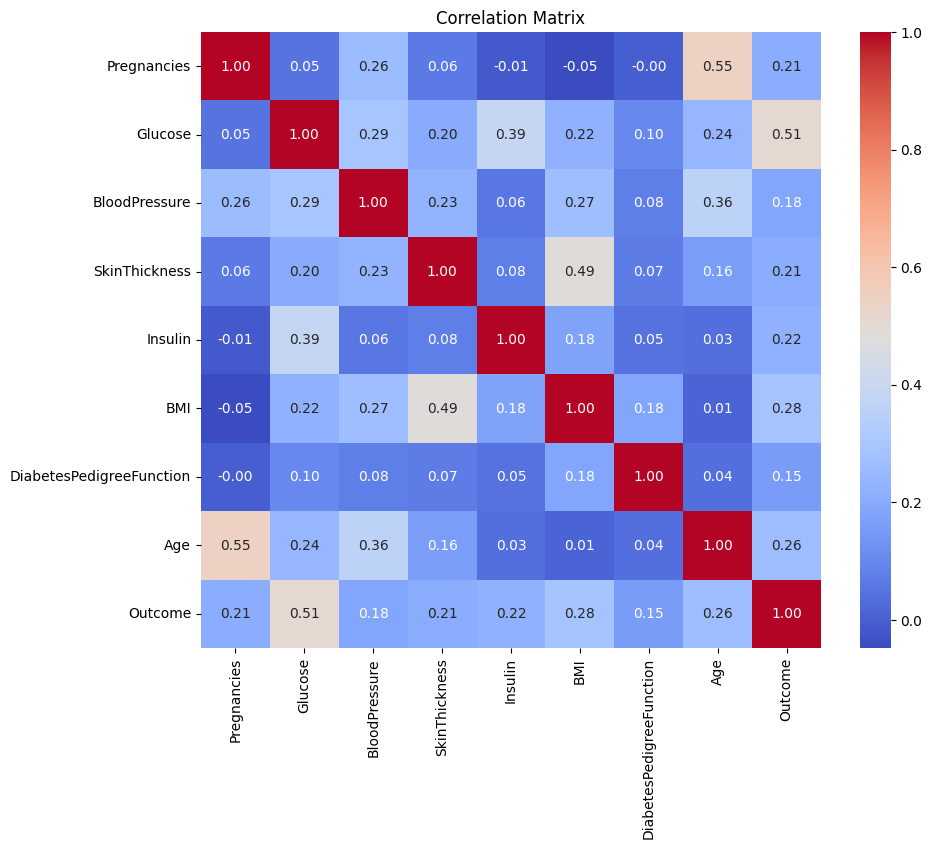

In [13]:
#Plot Correlation Matrix for Prioritization of Relevant Factors that contribute to diabetes diagnoses
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# **6. TRAIN-VALIDATION-TEST-SPLIT (70-20-10)**

To get started on training our model properly, we needed to split our dataset into three parts: training, validation, and test. The idea was to assign 70% of the data for training, 20% for validation, and the remaining 10% for testing. But instead of just slicing the dataset randomly, we made sure that each set kept the same proportion of people with and without diabetes. This is super important because if, say, the training set had mostly non-diabetic patients, the model might learn a bias and not generalize well.

So here's how we did it:
1. First, we split off the 10% test set and saved it for the very end. We won't touch this part until the model is completely trained and optimized.
Then, we split the remaining 90% into training and validation sets. But we didn't just do a 70-20 split out of the total data. We calculated the relative size of the validation set based on what's left after taking the test set out, which gave us a clean and proportionate 70-20-10 distribution overall.
2. We also used stratified sampling, which basically just means we preserved the balance of diabetic vs. non-diabetic cases in all the subsets.
Without this, the model might perform well on training but poorly on validation or testing, simply because the distribution was different.
By doing all this, we made sure that each part of our data was ready for its own role:
* Training set to teach the model
* Validation set to help improve its performance
*And test set to evaluate it properly when everything's ready

In short, we took the time to split things smartly so that our model can be trained, tuned, and tested in a structured and reliable way.

In [14]:
## 5. Train-Validation-Test Split

##The split will be:
# 70% for Training
# 20% for Validation
# 10% for Test

# Define features (X) and target (y) from the processed DataFrame
# Ensure 'target_column' variable is defined, typically 'Outcome'
target_column = 'Outcome' # Re-define if not already globally available from EDA section
X = df.drop(target_column, axis=1)
y = df[target_column]

train_ratio = 0.70
val_ratio = 0.20
test_ratio = 0.10

# --- First Split: Separate out the Test set ---
# We first split the data into a temporary training+validation set and the final test set.
# The test_size should be the actual test_ratio (0.10)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_ratio, random_state=42, stratify=y
)

In [15]:
# --- Second Split: Divide the remaining train+val set into Training and Validation ---
# The validation set size needs to be relative to the current X_train_val set.
# E.g., if train_ratio = 0.7 and val_ratio = 0.2, then the combined train_val is 0.9 of total.
# The validation set should be val_ratio / (train_ratio + val_ratio) of X_train_val.
relative_val_size_from_train_val = val_ratio / (train_ratio + val_ratio)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=relative_val_size_from_train_val, random_state=42, stratify=y_train_val
)

In [17]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Get feature names for later use in feature importance
feature_names_list = X_train.columns.tolist()

print("\n--- Final Split Percentages (Approximate) ---")
total_samples = len(df)
print(f"Training set:   {len(X_train)} samples ({len(X_train) / total_samples:.2%})")
print(f"Validation set: {len(X_val)} samples ({len(X_val) / total_samples:.2%})")
print(f"Test set:       {len(X_test)} samples ({len(X_test) / total_samples:.2%})")

X_train shape: (215, 8)
y_train shape: (215,)
X_val shape: (62, 8)
y_val shape: (62,)
X_test shape: (31, 8)
y_test shape: (31,)

--- Final Split Percentages (Approximate) ---
Training set:   215 samples (69.81%)
Validation set: 62 samples (20.13%)
Test set:       31 samples (10.06%)


# **7. MODEL DEVELOPMENT**

**7.1. CLASSIFICATION MODELS DICTIONARY**

We started by preparing a lineup of classification models we wanted to test. These include popular algorithms like K-Nearest Neighbors, Logistic Regression, Support Vector Machines, Random Forests, Gradient Boosting, and XGBoost. Each one offers a different approach to solving classification problems, so it’s useful to compare their strengths on our dataset.

Now, everyone might be wondering why the team chose classification models over linear regression models. With this, we should first look into the nature of the linear regression:

1. Linear regression is designed for predicting a continuous numerical output.
In this case, the target variable is "diabetes" (which we can represent as 0 or 1). This is a categorical or binary variable, not a continuous one.

2. Linear regression would try to fit a line to predict whether someone has 0 or 1 diabetes, which doesn't make logical sense. The output of a linear regression model is not constrained to this 0-1 range, and it doesn't represent probabilities.

In summary, linear regression is not ideal for predicting diabetes because diabetes is a categorical outcome, and linear regression is designed for continuous outcomes and makes assumptions that are not appropriate for this type of data. Logistic regression and other classification models are better choices because they are designed to handle categorical outputs and provide probabilities, which are essential for this task.



In [18]:
# --- Models Dictionary for Classification ---
models = {
    'K-NearestNeighbors': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
    'SVC': SVC(random_state=42, probability=True),
    'RandomForestClassifier': RandomForestClassifier(random_state=42, n_jobs=-1),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
    'XGBoostClassifier': xgb.XGBClassifier(
        random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
}

**7.2. CLASSIFICATION DICTIONARY FOR CLASSIFICATION MODELS**

Next, we created a dictionary of hyperparameters for each model. This tells our training process which settings to experiment like how many neighbors KNN should look at, or how deep a Random Forest should grow. By trying out different combinations, we can find the best version of each model.

In [19]:
# --- Parameters Dictionary for Classification Models ---
params = {
    'K-NearestNeighbors': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },

    'LogisticRegression': {
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    },

    'SVC': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 1],
        'kernel': ['rbf', 'linear']
    },

    'RandomForestClassifier': {
        'n_estimators': [100, 200, 500],
        'max_depth': [5, 10, None],
        'min_samples_leaf': [1, 2, 4],
        'min_samples_split': [2, 5, 10]
    },

    'GradientBoostingClassifier': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    },

    'XGBoostClassifier': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
}

print("Models and hyperparameters defined for classification.")

Models and hyperparameters defined for classification.


**7.3. MODELLING**

We then used a custom function called *auto_ml_classification* to do the heavy lifting. This function allows us to:

1. Setup: For each model, we build a pipeline that includes optional feature scaling and the model itself.

22. Search for Best Settings: Using grid search and cross-validation, the function automatically tests different hyperparameter combinations to find the best-performing one based on our chosen metric (in this case, ROC AUC).

3. Model Evaluation: Once the best version of the model is found, we evaluate how well it performs on the training, validation, and test sets using metrics like accuracy, F1 score, and ROC AUC.

4. Feature Insight: For models that allow it, we try to identify which input feature had the biggest impact on the prediction.

5. Results Recording: All performance results, along with the best parameters and runtime, are saved for easy comparison.

If anything goes wrong during this process—for example, a model doesn’t support certain features—it’s caught and logged, so the process can continue smoothly.

In [20]:
def auto_ml_classification(models, params,
                         X_train, y_train,
                         X_val, y_val,
                         X_test, y_test,
                         cv_folds=5,
                         scoring='roc_auc',
                         scaling_method='standard',
                         feature_names=None,
                         random_state=42): # Added random_state
    """
    Automates model training, hyperparameter tuning, and evaluation for classification tasks.

    This function leverages GridSearchCV with a pipeline to handle scaling and model training,
    and evaluates models using a range of classification metrics.

    Args:
        models (dict): Dictionary of initialized scikit-learn compatible models
                        (e.g., {'LogisticRegression': LogisticRegression()}).
        params (dict): Dictionary of parameter grids for each model, matching keys
                        in 'models' (e.g., {'LogisticRegression': {'penalty': ['l1', 'l2']}}).
        X_train (pd.DataFrame or np.ndarray): Training features.
        y_train (pd.Series or np.ndarray): Training target variable.
        X_val (pd.DataFrame or np.ndarray): Validation features.
        y_val (pd.Series or np.ndarray): Validation target variable.
        X_test (pd.DataFrame or np.ndarray): Test features.
        y_test (pd.Series or np.ndarray): Test target variable.
        cv_folds (int): Number of folds for Stratified K-Fold cross-validation in GridSearchCV.
        scoring (str): Scoring metric for GridSearchCV (e.g., 'accuracy', 'roc_auc', 'f1').
        scaling_method (str): Feature scaling method: 'standard', 'minmax', or 'none'.
        feature_names (list, optional): List of feature names. If None and X_train
                                        is a DataFrame, names are inferred. Needed for
                                        reporting top features.
        random_state (int):  Added for consistent results # Make it a parameter

    Returns:
        pd.DataFrame: DataFrame containing evaluation results for each model.
        dict: Dictionary of best fitted models for each type.
    """

    results_list = []
    best_models_dict = {}
    if feature_names is None and isinstance(X_train, pd.DataFrame):
        feature_names = X_train.columns.tolist()

    print(f"Starting AutoML Classification Process...")
    print(f"CV Folds: {cv_folds}, Scaling: {scaling_method}, Scoring: {scoring}, Random State: {random_state}") #show random state
    print("-" * 30)

    for name, model in models.items():
        start_time = time.time()
        print(f"Processing Model: {name}...")

        try:
            # --- 1. Create Pipeline with Scaling ---
            steps = []
            if scaling_method == 'standard':
                scaler = StandardScaler()
                steps.append(('scaler', scaler))
                print("  - Using StandardScaler")
            elif scaling_method == 'minmax':
                scaler = MinMaxScaler()
                steps.append(('scaler', scaler))
                print("  - Using MinMaxScaler")
            else:
                print("  - No scaling applied")

            # Add model step
            steps.append(('model', model))
            pipeline = Pipeline(steps)

            # --- 2. Prepare Parameter Grid for Pipeline ---
            param_grid_pipeline = {}
            if name in params:
                for key, value in params[name].items():
                    param_grid_pipeline[f'model__{key}'] = value
            else:
                print(f"  - Warning: No parameter grid found for {name}. Using default parameters.")

            # --- 3. Grid Search with Stratified K-Fold Cross-Validation ---
            print(f"  - Running GridSearchCV with {cv_folds}-Fold Stratified CV...")
            # Using StratifiedKFold for classification tasks to maintain class balance
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state) #use random state
            grid_search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid_pipeline,
                cv=cv,
                scoring=scoring,
                n_jobs=-1,
                refit=True
            )

            # Fit GridSearchCV on the training data
            grid_search.fit(X_train, y_train)
            best_pipeline = grid_search.best_estimator_
            best_params_raw = grid_search.best_params_

            # Clean up best_params keys (remove 'model__')
            best_params_cleaned = {key.replace('model__', ''): val for key, val in best_params_raw.items()}
            print(f"  - Best CV Score ({scoring}): {grid_search.best_score_:.4f}")
            print(f"  - Best Params: {best_params_cleaned}")

            best_models_dict[name] = best_pipeline # Store the best fitted pipeline

            # --- 4. Evaluate on Train, Validation, Test Sets using Classification Metrics ---
            print("  - Evaluating best model...")
            # Predict probabilities for ROC AUC (if model supports it)
            y_train_pred_proba = best_pipeline.predict_proba(X_train)[:, 1] if hasattr(best_pipeline, 'predict_proba') else np.array([np.nan]*len(y_train))
            y_train_pred = best_pipeline.predict(X_train)

            y_val_pred_proba = best_pipeline.predict_proba(X_val)[:, 1] if hasattr(best_pipeline, 'predict_proba') else np.array([np.nan]*len(y_val))
            y_val_pred = best_pipeline.predict(X_val)

            y_test_pred_proba = best_pipeline.predict_proba(X_test)[:, 1] if hasattr(best_pipeline, 'predict_proba') else np.array([np.nan]*len(y_test))
            y_test_pred = best_pipeline.predict(X_test)

            # Calculate common classification metrics
            train_accuracy = accuracy_score(y_train, y_train_pred)
            val_accuracy = accuracy_score(y_val, y_val_pred)
            test_accuracy = accuracy_score(y_test, y_test_pred)

            train_roc_auc = roc_auc_score(y_train, y_train_pred_proba) if hasattr(best_pipeline, 'predict_proba') else np.nan
            val_roc_auc = roc_auc_score(y_val, y_val_pred_proba) if hasattr(best_pipeline, 'predict_proba') else np.nan
            test_roc_auc = roc_auc_score(y_test, y_test_pred_proba) if hasattr(best_pipeline, 'predict_proba') else np.nan


            train_precision = precision_score(y_train, y_train_pred, zero_division=0)
            val_precision = precision_score(y_val, y_val_pred, zero_division=0)
            test_precision = precision_score(y_test, y_test_pred, zero_division=0)

            train_recall = recall_score(y_train, y_train_pred, zero_division=0)
            val_recall = recall_score(y_val, y_val_pred, zero_division=0)
            test_recall = recall_score(y_test, y_test_pred, zero_division=0)

            train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
            val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
            test_f1 = f1_score(y_test, y_test_pred, zero_division=0)



            print(f"  - Train Accuracy: {train_accuracy:.4f}, ROC AUC: {train_roc_auc:.4f}, F1: {train_f1:.4f}")
            print(f"  - Validation Accuracy: {val_accuracy:.4f}, ROC AUC: {val_roc_auc:.4f}, F1: {val_f1:.4f}")
            print(f"  - Test Accuracy: {test_accuracy:.4f}, ROC AUC: {test_roc_auc:.4f}, F1: {test_f1:.4f}")

            # Print Classification Report and Confusion Matrix for Test Set
            print("\n  --- Test Set Classification Report ---")
            print(classification_report(y_test, y_test_pred, zero_division=0))
            print("\n  --- Test Set Confusion Matrix ---")
            cm = confusion_matrix(y_test, y_test_pred)
            print(cm)
            # Visualize Confusion Matrix
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
            disp.plot(cmap='Blues')
            plt.title(f'Confusion Matrix for {name} (Test Set)')
            plt.show()



            # --- 5. Extract Top Feature (if available) ---
            top_feature = 'N/A'
            if feature_names:
                try:
                    final_model = best_pipeline.named_steps['model']
                    if hasattr(final_model, 'feature_importances_'):
                        importances = final_model.feature_importances_
                        if len(importances) == len(feature_names):
                            idx = np.argmax(importances)
                            top_feature = f"{feature_names[idx]} ({importances[idx]:.4f})"
                            print(f"  - Top Feature (Importance): {top_feature}")
                        else:
                            print("  - Feature importances array length mismatch with feature names.")
                    elif hasattr(final_model, 'coef_'):
                        coefficients = final_model.coef_
                        if coefficients.ndim == 1: # For binary classification with LogisticRegression
                            idx = np.argmax(np.abs(coefficients))
                            top_feature = f"{feature_names[idx]} ({coefficients[idx]:.4f})"
                            print(f"  - Top Feature (Coefficient): {top_feature}")
                        elif coefficients.ndim == 2 and coefficients.shape[0] == 1: # Some models return 2D array for coef_ even for binary
                            idx = np.argmax(np.abs(coefficients[0]))
                            top_feature = f"{feature_names[idx]} ({coefficients[0][idx]:.4f})"
                            print(f"  - Top Feature (Coefficient): {top_feature}")
                        else:
                            print("  - Coefficient shape indicates multi-class or multi-output, skipping simple top feature.")
                            top_feature = 'N/A (Multi-class/output)'
                    else:
                        print("  - Model type does not provide standard feature importances or coefficients.")

                except (AttributeError, IndexError, NotFittedError) as e:
                    print(f"  - Could not extract feature importances/coefficients: {e}")
                    top_feature = 'Error'
            else:
                print("  - Feature names not provided, skipping top feature extraction.")


            # --- 6. Record Runtime & Results ---
            end_time = time.time()
            runtime = end_time - start_time
            print(f"  - Runtime: {runtime:.2f} seconds")

            results_list.append({
                'Model': name,
                'Train Accuracy': train_accuracy,
                'Val Accuracy': val_accuracy,
                'Test Accuracy': test_accuracy,
                'Train ROC AUC': train_roc_auc,
                'Val ROC AUC': val_roc_auc,
                'Test ROC AUC': test_roc_auc,
                'Train F1-Score': train_f1,
                'Val F1-Score': val_f1,
                'Test F1-Score': test_f1,
                'Best Parameters': best_params_cleaned if best_params_cleaned else 'Default',
                'Top Feature': top_feature,
                'Run Time (s)': round(runtime, 2)
            })

        except Exception as e:
            end_time = time.time()
            runtime = end_time - start_time
            print(f"  - ERROR processing model {name}: {e}")
            # Optionally log the full traceback here
            import traceback
            traceback.print_exc() # Print full traceback for debugging
            results_list.append({
                'Model': name,
                'Train Accuracy': np.nan,
                'Val Accuracy': np.nan,
                'Test Accuracy': np.nan,
                'Train ROC AUC': np.nan,
                'Val ROC AUC': np.nan,
                'Train F1-Score': np.nan,
                'Val F1-Score': np.nan,
                'Test F1-Score': np.nan,
                'Best Parameters': 'Error',
                'Top Feature': 'Error',
                'Run Time (s)': round(runtime, 2)
            })

        print("-" * 30)

    print("AutoML Classification Process Completed.")

    # --- 7. Tabulate Results ---
    results_df = pd.DataFrame(results_list)
    # Sort by Test ROC AUC for a balanced view of classification performance
    results_df = results_df.sort_values(by='Test ROC AUC', ascending=False)

    return results_df, best_models_dict

**7.4. MODEL EVALUATION**

We now execute the automated training and evaluation function for our selected models. The primary scoring metric for hyperparameter tuning is set to ROC AUC, as it provides a robust measure of model performance across various threshold settings, especially in imbalanced classification tasks.

The following configuration is used:

Cross-validation: 5-fold, to ensure robust model performance assessment (suggested by AI)

Scoring metric: roc_auc, to prioritize the balance between sensitivity and specificity (suggested by AI)

Scaling method: StandardScaler, applied to all features to normalize input distributions

Starting AutoML Classification Process...
CV Folds: 5, Scaling: standard, Scoring: roc_auc, Random State: 42
------------------------------
Processing Model: K-NearestNeighbors...
  - Using StandardScaler
  - Running GridSearchCV with 5-Fold Stratified CV...
  - Best CV Score (roc_auc): 0.8221
  - Best Params: {'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
  - Evaluating best model...
  - Train Accuracy: 0.8093, ROC AUC: 0.8794, F1: 0.6435
  - Validation Accuracy: 0.7903, ROC AUC: 0.8543, F1: 0.6061
  - Test Accuracy: 0.7097, ROC AUC: 0.7500, F1: 0.5263

  --- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        22
           1       0.50      0.56      0.53         9

    accuracy                           0.71        31
   macro avg       0.65      0.66      0.66        31
weighted avg       0.72      0.71      0.71        31


  --- Test Set Confusion Matrix ---
[[17  5]
 [ 4  5]]


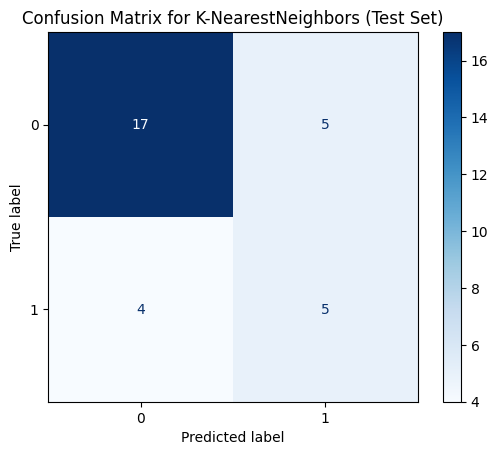

  - Model type does not provide standard feature importances or coefficients.
  - Runtime: 5.33 seconds
------------------------------
Processing Model: LogisticRegression...
  - Using StandardScaler
  - Running GridSearchCV with 5-Fold Stratified CV...
  - Best CV Score (roc_auc): 0.8687
  - Best Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
  - Evaluating best model...
  - Train Accuracy: 0.7953, ROC AUC: 0.8702, F1: 0.6562
  - Validation Accuracy: 0.8387, ROC AUC: 0.8494, F1: 0.7222
  - Test Accuracy: 0.7419, ROC AUC: 0.7828, F1: 0.5556

  --- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        22
           1       0.56      0.56      0.56         9

    accuracy                           0.74        31
   macro avg       0.69      0.69      0.69        31
weighted avg       0.74      0.74      0.74        31


  --- Test Set Confusion Matrix ---
[[18  4]
 [ 4  5]]


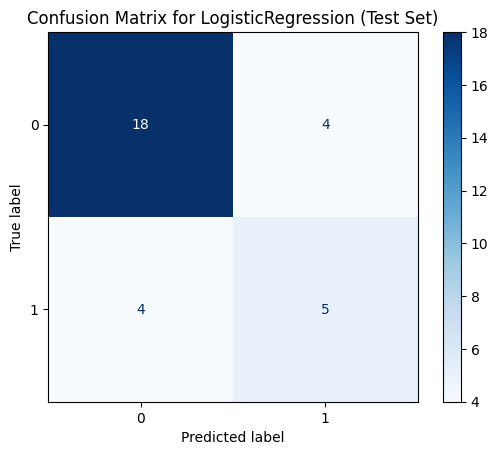

  - Top Feature (Coefficient): Glucose (0.2997)
  - Runtime: 0.82 seconds
------------------------------
Processing Model: SVC...
  - Using StandardScaler
  - Running GridSearchCV with 5-Fold Stratified CV...
  - Best CV Score (roc_auc): 0.8687
  - Best Params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
  - Evaluating best model...
  - Train Accuracy: 0.8093, ROC AUC: 0.8815, F1: 0.6555
  - Validation Accuracy: 0.7903, ROC AUC: 0.8617, F1: 0.6286
  - Test Accuracy: 0.8065, ROC AUC: 0.8535, F1: 0.6667

  --- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        22
           1       0.67      0.67      0.67         9

    accuracy                           0.81        31
   macro avg       0.77      0.77      0.77        31
weighted avg       0.81      0.81      0.81        31


  --- Test Set Confusion Matrix ---
[[19  3]
 [ 3  6]]


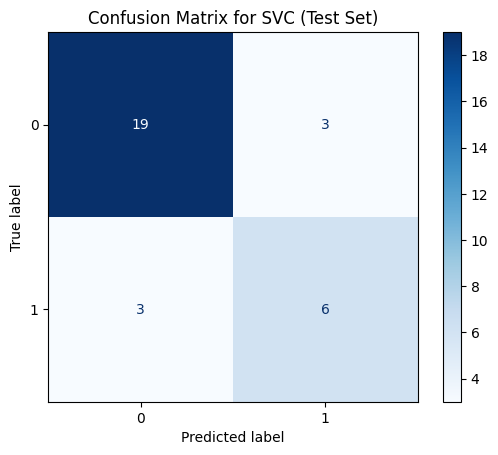

  - Top Feature (Coefficient): Glucose (1.2305)
  - Runtime: 8.10 seconds
------------------------------
Processing Model: RandomForestClassifier...
  - Using StandardScaler
  - Running GridSearchCV with 5-Fold Stratified CV...
  - Best CV Score (roc_auc): 0.8579
  - Best Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
  - Evaluating best model...
  - Train Accuracy: 0.9116, ROC AUC: 0.9769, F1: 0.8504
  - Validation Accuracy: 0.8065, ROC AUC: 0.8103, F1: 0.6471
  - Test Accuracy: 0.7419, ROC AUC: 0.7828, F1: 0.5556

  --- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        22
           1       0.56      0.56      0.56         9

    accuracy                           0.74        31
   macro avg       0.69      0.69      0.69        31
weighted avg       0.74      0.74      0.74        31


  --- Test Set Confusion Matrix ---
[[18  4]
 [ 4  5]]


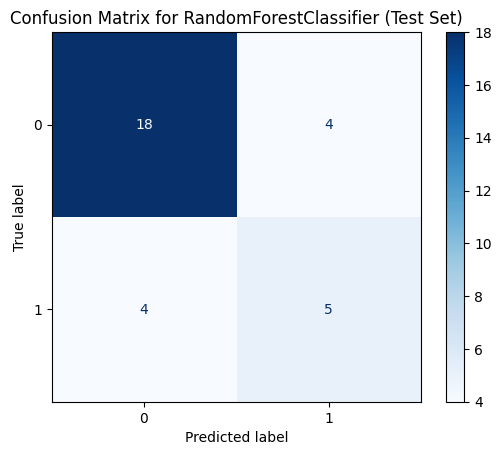

  - Top Feature (Importance): Glucose (0.3821)
  - Runtime: 221.27 seconds
------------------------------
Processing Model: GradientBoostingClassifier...
  - Using StandardScaler
  - Running GridSearchCV with 5-Fold Stratified CV...
  - Best CV Score (roc_auc): 0.8313
  - Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
  - Evaluating best model...
  - Train Accuracy: 0.9721, ROC AUC: 0.9971, F1: 0.9524
  - Validation Accuracy: 0.8065, ROC AUC: 0.8409, F1: 0.6471
  - Test Accuracy: 0.7419, ROC AUC: 0.7879, F1: 0.5556

  --- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        22
           1       0.56      0.56      0.56         9

    accuracy                           0.74        31
   macro avg       0.69      0.69      0.69        31
weighted avg       0.74      0.74      0.74        31


  --- Test Set Confusion Matrix ---
[[18  4]
 [ 4  5]]


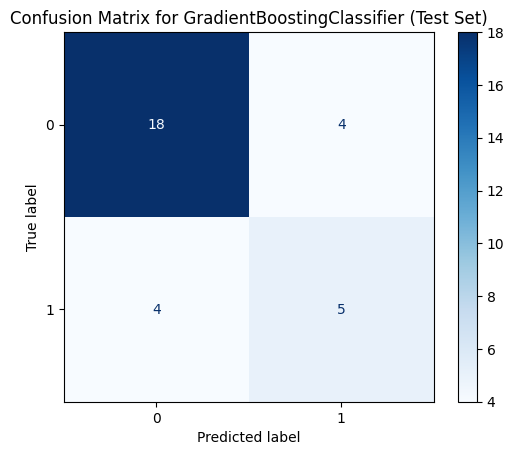

  - Top Feature (Importance): Glucose (0.3915)
  - Runtime: 198.52 seconds
------------------------------
Processing Model: XGBoostClassifier...
  - Using StandardScaler
  - Running GridSearchCV with 5-Fold Stratified CV...
  - Best CV Score (roc_auc): 0.8518
  - Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  - Evaluating best model...
  - Train Accuracy: 0.9256, ROC AUC: 0.9833, F1: 0.8730
  - Validation Accuracy: 0.8226, ROC AUC: 0.8372, F1: 0.6667
  - Test Accuracy: 0.7419, ROC AUC: 0.8131, F1: 0.5556

  --- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        22
           1       0.56      0.56      0.56         9

    accuracy                           0.74        31
   macro avg       0.69      0.69      0.69        31
weighted avg       0.74      0.74      0.74        31


  --- Test Set Confusion Matrix ---
[[18  4]
 [ 

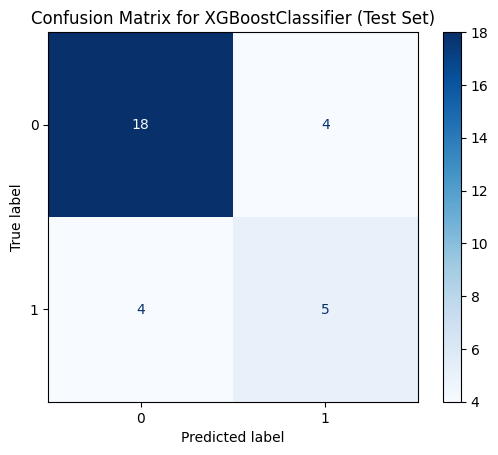

  - Top Feature (Importance): Glucose (0.2775)
  - Runtime: 43.78 seconds
------------------------------
AutoML Classification Process Completed.

--- AutoML Classification Results Summary ---


,Model,Train Accuracy,Val Accuracy,Test Accuracy,Train ROC AUC,Val ROC AUC,Test ROC AUC,Train F1-Score,Val F1-Score,Test F1-Score,Best Parameters,Top Feature,Run Time (s)
2,SVC,0.809302,0.790323,0.806452,0.881538,0.861689,0.853535,0.655462,0.628571,0.666667,"{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}",Glucose (1.2305),8.10
5,XGBoostClassifier,0.925581,0.822581,0.741935,0.983282,0.837209,0.813131,0.873016,0.666667,0.555556,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",Glucose (0.2775),43.78
4,GradientBoostingClassifier,0.972093,0.806452,0.741935,0.997128,0.840881,0.787879,0.952381,0.647059,0.555556,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",Glucose (0.3915),198.52
1,LogisticRegression,0.795349,0.838710,0.741935,0.870154,0.849449,0.782828,0.656250,0.722222,0.555556,"{'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...",Glucose (0.2997),0.82
3,RandomForestClassifier,0.911628,0.806452,0.741935,0.976923,0.810282,0.782828,0.850394,0.647059,0.555556,"{'max_depth': 10, 'min_samples_leaf': 4, 'min_...",Glucose (0.3821),221.27
0,K-NearestNeighbors,0.809302,0.790323,0.709677,0.879436,0.854345,0.750000,0.643478,0.606061,0.526316,"{'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}",N/A,5.33


In [21]:
# ============================ 7. MODEL EVALUATION ============================
"""
## 7. Model Evaluation

### Running the AutoML Classification Process

We now execute the automated function to train and evaluate our selected models. The primary scoring metric for hyperparameter tuning will be `ROC AUC`.
"""
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

results_table_classification, best_fitted_models = auto_ml_classification(
    models=models,
    params=params,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    cv_folds=5, # Using 5-fold cross-validation for robust tuning
    scoring='roc_auc', # Prioritizing ROC AUC for hyperparameter tuning
    scaling_method='standard', # Standard scaling applied to all features
    feature_names=feature_names_list
)

print("\n--- AutoML Classification Results Summary ---")
display(results_table_classification)

To objectively evaluate which model balances performance across different metrics, the team computed a Combined Score by weighting three key metrics: Accuracy (50%), ROC AUC (30%), and F1-Score (20%). Each metric was also internally weighted based on its relevance across datasets: 10% Train, 40% Validation, and 50% Test, to prioritize generalization and real-world performance.

In [22]:
data = {
    'Model': ['SVC', 'XGBoost', 'GradientBoosting', 'LogisticRegression', 'RandomForest', 'KNN'],
    'Train Accuracy': [0.809302, 0.925581, 0.972093, 0.795349, 0.911628, 0.809302],
    'Val Accuracy': [0.790323, 0.822581, 0.806452, 0.838710, 0.806452, 0.790323],
    'Test Accuracy': [0.806452, 0.741935, 0.741935, 0.741935, 0.741935, 0.709677],
    'Train ROC AUC': [0.881538, 0.983282, 0.997128, 0.870154, 0.976923, 0.879436],
    'Val ROC AUC': [0.861689, 0.837209, 0.840881, 0.849449, 0.810282, 0.854345],
    'Test ROC AUC': [0.853535, 0.813131, 0.787879, 0.782828, 0.782828, 0.750000],
    'Train F1': [0.655462, 0.873016, 0.952381, 0.656250, 0.850394, 0.643478],
    'Val F1': [0.628571, 0.666667, 0.647059, 0.722222, 0.647059, 0.606061],
    'Test F1': [0.666667, 0.555556, 0.555556, 0.555556, 0.555556, 0.526316]
}

# Create DataFrame
df = pd.DataFrame(data)

# Compute weighted scores for each metric type
df['Accuracy Score'] = (
    0.10 * df['Train Accuracy'] +
    0.40 * df['Val Accuracy'] +
    0.50 * df['Test Accuracy']
)

df['ROC AUC Score'] = (
    0.10 * df['Train ROC AUC'] +
    0.40 * df['Val ROC AUC'] +
    0.50 * df['Test ROC AUC']
)

df['F1 Score'] = (
    0.10 * df['Train F1'] +
    0.40 * df['Val F1'] +
    0.50 * df['Test F1']
)

# Final combined weighted score
df['Combined Score'] = (
    0.50 * df['Accuracy Score'] +
    0.30 * df['ROC AUC Score'] +
    0.20 * df['F1 Score']
)

# Sort by combined score
df_sorted = df.sort_values(by='Combined Score', ascending=False)

# Show results
print(df_sorted[['Model', 'Accuracy Score', 'ROC AUC Score', 'F1 Score', 'Combined Score']])

                Model  Accuracy Score  ROC AUC Score  F1 Score  Combined Score
0                 SVC        0.800285       0.859597  0.650308        0.788083
1             XGBoost        0.792558       0.839777  0.631746        0.774561
2    GradientBoosting        0.790758       0.830005  0.631840        0.770748
3  LogisticRegression        0.785986       0.818209  0.632292        0.764914
4        RandomForest        0.784711       0.813219  0.621641        0.760649
5                 KNN        0.751898       0.804682  0.569930        0.731339


**Interpretation of the Results**

To better visualize and appreciate the results of the modelling, the following are the team's summarized inputs, insights, conlusions, and recommendations:




*   XGBoost, Gradient Boosting, and Random Forest showed the highest training accuracies, but all three experienced a noticeable drop in validation and test performance, suggesting potential overfitting.

* Logistic Regression, despite being a simpler model, achieved the highest validation accuracy (83.87%) and a balanced ROC AUC across all datasets, indicating good generalization and stability.

* The Support Vector Classifier (SVC) maintained consistent performance across train, validation, and test sets, with decent F1-scores and AUC values—suggesting reliable and generalizable results.

* K-Nearest Neighbors had the lowest test accuracy and F1-score, making it the least effective among the models.

* Top Feature across nearly all models was Glucose, highlighting its strong predictive value for the target outcome.

* Overall, SVC (Support Vector Classifier) emerged as the top-performing model, achieving the highest Combined Score. It demonstrated consistent performance across all datasets and metrics, indicating strong generalization without overfitting. It was especially balanced in terms of accuracy and ROC AUC, making it a robust choice.


# **8. Summary of Model Results Visualization**

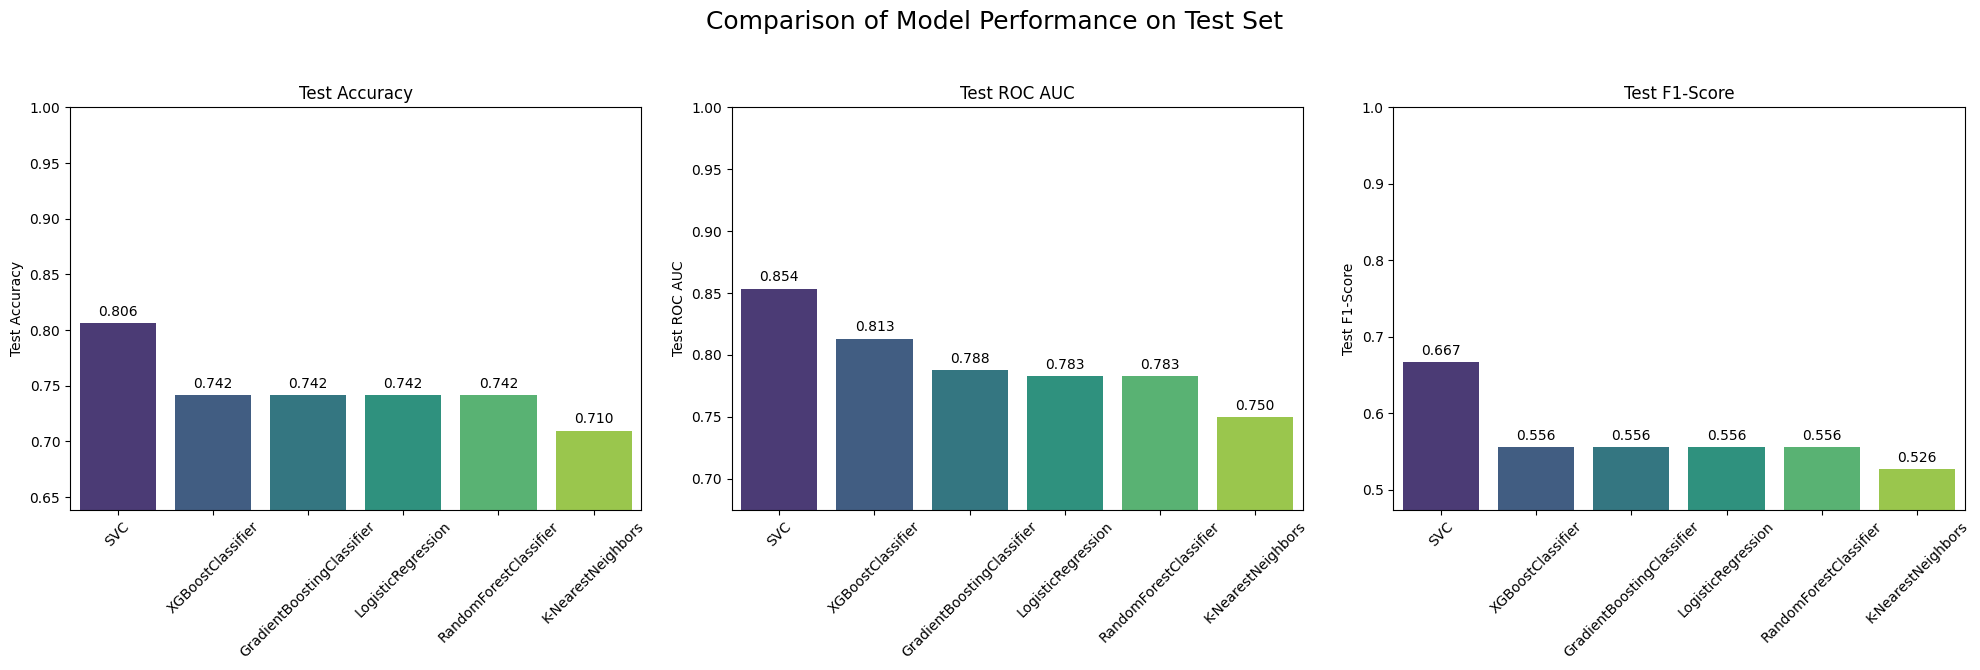

In [23]:
### Visualizing Model Performance

# Define metrics to plot. You can choose which ones are most relevant.
metrics_to_plot = ['Test Accuracy', 'Test ROC AUC', 'Test F1-Score']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 7), sharey=False) # Adjusted figure size
fig.suptitle('Comparison of Model Performance on Test Set', fontsize=18)

for i, metric in enumerate(metrics_to_plot):
    # Sort models by the current metric for better visualization
    sorted_results = results_table_classification.sort_values(by=metric, ascending=False)
    sns.barplot(x='Model', y=metric, data=sorted_results, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric}')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('') # Remove x-label as it's repetitive
    axes[i].tick_params(axis='x', rotation=45) # Corrected: Removed 'ha='right''
    axes[i].set_ylim(sorted_results[metric].min() * 0.9, 1.0) # Set dynamic y-axis limit, ensuring it doesn't start too high
    # Add value labels on top of bars for clarity
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', label_type='edge', padding=3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
